# Barça de Guardiola: 2008-09 vs 2010-11

Comparación de las dos ligas que ganó el Barça de Guardiola con datos abiertos.


In [1]:
!pip install mplsoccer -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 1.3 MB/s eta 0:00:00


In [2]:
import os, zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import Pitch, VerticalPitch

pd.set_option('display.max_columns', 40)
GRANA, AZUL, ORO = '#A50044', '#004D98', '#EDBB00'
T = ['2008-09', '2010-11']

## 1. Carga de datos

In [ ]:
if not os.path.exists('statsbomb_eventos.csv'):
    from google.colab import files
    subidos = files.upload()
    for f in subidos:
        if f.endswith('.zip'):
            zipfile.ZipFile(f).extractall()

liga = pd.read_csv('liga_resultados.csv')
partidos = pd.read_csv('statsbomb_partidos.csv')
eventos = pd.read_csv('statsbomb_eventos.csv', low_memory=False)
minutos = pd.read_csv('statsbomb_minutos.csv')

for nombre, df in [('liga', liga), ('partidos', partidos), ('eventos', eventos), ('minutos', minutos)]:
    print(nombre, df.shape)

liga (760, 22)
partidos (64, 12)
eventos (236537, 20)
minutos (1776, 7)


| Archivo | Qué tiene |
|---|---|
| `liga_resultados.csv` | Los 380 partidos de cada liga: goles, goles al descanso, tiros, tiros al arco, faltas, córners, tarjetas |
| `statsbomb_partidos.csv` | Los partidos del Barça que tiene StatsBomb, con rival, condición y marcador |
| `statsbomb_eventos.csv` | Cada acción con balón de ambos equipos: tipo, jugador, coordenadas, resultado, receptor del pase, xG |
| `statsbomb_minutos.csv` | Minutos jugados por jugador en cada partido (calculados con titulares, cambios y expulsiones) |

In [ ]:
eventos.head()

,temporada,match_id,periodo,minuto,segundo,equipo,jugador,posicion,tipo,x,y,x_fin,y_fin,resultado,receptor,asistencia,xg,parte_cuerpo,bajo_presion,patron_juego
0,2008-09,69147,1,0,1,Barcelona,Samuel Eto'o,Center Forward,Pass,60.0,40.0,59.7,42.0,Completo,Andrés Iniesta,NaN,NaN,NaN,0,From Kick Off
1,2008-09,69147,1,0,1,Barcelona,Andrés Iniesta,Right Center Midfield,Ball Receipt*,59.7,42.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,From Kick Off
2,2008-09,69147,1,0,1,Barcelona,Andrés Iniesta,Right Center Midfield,Carry,59.7,42.0,57.1,41.8,NaN,NaN,NaN,NaN,NaN,0,From Kick Off
3,2008-09,69147,1,0,2,Barcelona,Andrés Iniesta,Right Center Midfield,Pass,57.1,41.8,54.2,52.1,Completo,Xavi,NaN,NaN,NaN,0,From Kick Off
4,2008-09,69147,1,0,3,Barcelona,Xavi,Left Center Midfield,Ball Receipt*,54.2,52.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,From Kick Off


In [ ]:
partidos.groupby('temporada').agg(partidos=('match_id', 'size'), gf=('gf', 'sum'), gc=('gc', 'sum'))

,partidos,gf,gc
temporada,,,
2008-09,31,94,29
2010-11,33,86,18


# La liga (38 partidos)

In [ ]:
local = liga.rename(columns={'HomeTeam': 'equipo', 'AwayTeam': 'rival', 'FTHG': 'gf', 'FTAG': 'gc',
                             'HTHG': 'gf_1t', 'HTAG': 'gc_1t', 'HS': 'tiros', 'AS': 'tiros_rival',
                             'HST': 'al_arco', 'AST': 'al_arco_rival'})
local['condicion'] = 'Local'

visita = liga.rename(columns={'AwayTeam': 'equipo', 'HomeTeam': 'rival', 'FTAG': 'gf', 'FTHG': 'gc',
                              'HTAG': 'gf_1t', 'HTHG': 'gc_1t', 'AS': 'tiros', 'HS': 'tiros_rival',
                              'AST': 'al_arco', 'HST': 'al_arco_rival'})
visita['condicion'] = 'Visita'

cols = ['temporada', 'Date', 'equipo', 'rival', 'condicion', 'gf', 'gc', 'gf_1t', 'gc_1t',
        'tiros', 'tiros_rival', 'al_arco', 'al_arco_rival']
eq = pd.concat([local[cols], visita[cols]]).sort_values(['temporada', 'Date'])
eq['puntos'] = np.select([eq.gf > eq.gc, eq.gf == eq.gc], [3, 1], 0)
eq['jornada'] = eq.groupby(['temporada', 'equipo']).cumcount() + 1
eq.head()

,temporada,Date,equipo,rival,condicion,gf,gc,gf_1t,gc_1t,tiros,tiros_rival,al_arco,al_arco_rival,puntos,jornada
0,2008-09,2008-08-30,Espanol,Valladolid,Local,1,0,0,0,10,11,2,1,3,1
1,2008-09,2008-08-30,Valencia,Mallorca,Local,3,0,2,0,17,16,6,2,3,1
0,2008-09,2008-08-30,Valladolid,Espanol,Visita,0,1,0,0,11,10,1,2,0,1
1,2008-09,2008-08-30,Mallorca,Valencia,Visita,0,3,0,2,16,17,2,6,0,1
2,2008-09,2008-08-31,Ath Bilbao,Almeria,Local,1,3,0,2,10,11,4,5,0,1


## Tabla de posiciones

In [ ]:
tabla = eq.groupby(['temporada', 'equipo']).agg(
    Pts=('puntos', 'sum'),
    G=('puntos', lambda x: (x == 3).sum()),
    E=('puntos', lambda x: (x == 1).sum()),
    P=('puntos', lambda x: (x == 0).sum()),
    GF=('gf', 'sum'),
    GC=('gc', 'sum')).reset_index()
tabla['DG'] = tabla.GF - tabla.GC
tabla = tabla.sort_values(['temporada', 'Pts', 'DG'], ascending=[True, False, False])
tabla.groupby('temporada').head(4)

,temporada,equipo,Pts,G,E,P,GF,GC,DG
3,2008-09,Barcelona,87,27,6,5,105,35,70
12,2008-09,Real Madrid,78,25,3,10,83,52,31
15,2008-09,Sevilla,70,21,7,10,54,39,15
2,2008-09,Ath Madrid,67,20,7,11,80,57,23
23,2010-11,Barcelona,96,30,6,2,95,21,74
32,2010-11,Real Madrid,92,29,5,4,102,33,69
37,2010-11,Valencia,71,21,8,9,64,44,20
38,2010-11,Villarreal,62,18,8,12,54,44,10


## Resumen del Barça

In [ ]:
barca = eq[eq.equipo == 'Barcelona']
g = barca.groupby('temporada')

resumen = g.agg(
    puntos=('puntos', 'sum'),
    goles_favor=('gf', 'sum'),
    goles_contra=('gc', 'sum'),
    vallas_invictas=('gc', lambda x: (x == 0).sum()),
    tiros_pp=('tiros', 'mean'),
    tiros_rival_pp=('tiros_rival', 'mean'),
    al_arco_pp=('al_arco', 'mean'),
    al_arco_rival_pp=('al_arco_rival', 'mean'))
resumen['conversion_%'] = g.gf.sum() / g.al_arco.sum() * 100
resumen['conversion_rival_%'] = g.gc.sum() / g.al_arco_rival.sum() * 100
resumen.round(1).T

temporada,2008-09,2010-11
puntos,87.0,96.0
goles_favor,105.0,95.0
goles_contra,35.0,21.0
vallas_invictas,15.0,19.0
tiros_pp,18.6,15.6
tiros_rival_pp,7.0,7.4
al_arco_pp,7.3,7.2
al_arco_rival_pp,2.9,2.9
conversion_%,38.0,34.7
conversion_rival_%,32.1,19.3


## A3. Carrera por el título

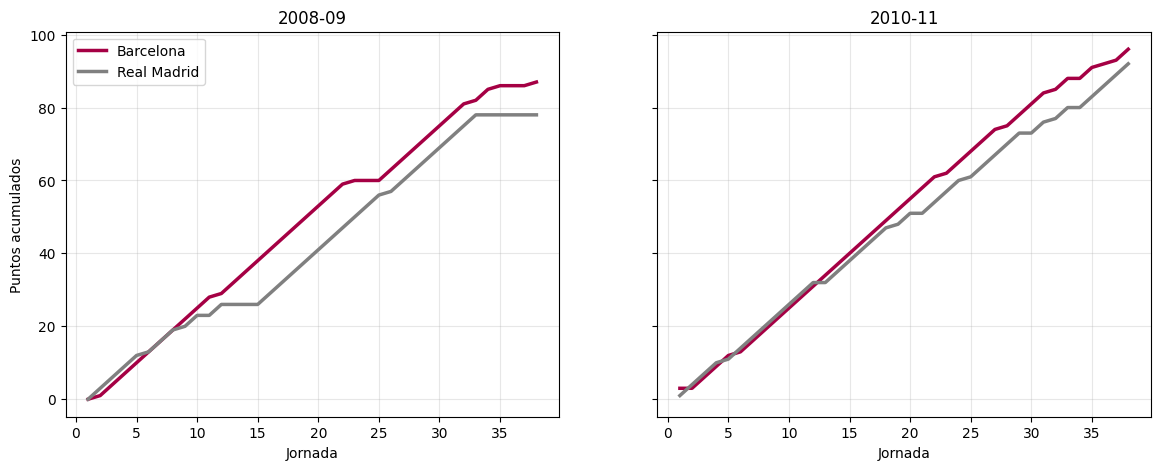

2008-09 | ventaja final: 9 | máxima: 12 | mínima: -2
2010-11 | ventaja final: 4 | máxima: 8 | mínima: -1


In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, t in zip(axs, T):
    for equipo, color in [('Barcelona', GRANA), ('Real Madrid', 'gray')]:
        d = eq[(eq.temporada == t) & (eq.equipo == equipo)]
        ax.plot(d.jornada, d.puntos.cumsum(), color=color, lw=2.5, label=equipo)
    ax.set_title(t)
    ax.set_xlabel('Jornada')
    ax.grid(alpha=.3)
axs[0].set_ylabel('Puntos acumulados')
axs[0].legend()
plt.show()

for t in T:
    d = eq[eq.temporada == t].pivot_table(index='jornada', columns='equipo', values='puntos', aggfunc='sum').cumsum()
    dif = d['Barcelona'] - d['Real Madrid']
    print(t, '| ventaja final:', dif.iloc[-1], '| máxima:', dif.max(), '| mínima:', dif.min())

 En 2008-09 el Barça llegó a sacarle 12 puntos al Madrid y ganó con 9 de ventaja. En 2010-11 la liga fue mucho más apretada: el Madrid hizo 92 puntos (14 más que en 2008-09) y la ventaja máxima del Barça fue de 8. Los 96 puntos de 2010-11 hacían falta porque el rival era más fuerte.

## El Barça comparado con su liga

Los números absolutos de 2009 y 2011 no se comparan bien porque cada liga tiene su propio nivel. Por eso calculo el **z-score** de cada indicador: cuántas desviaciones estándar está el Barça por encima o por debajo del promedio de los 20 equipos de esa temporada.

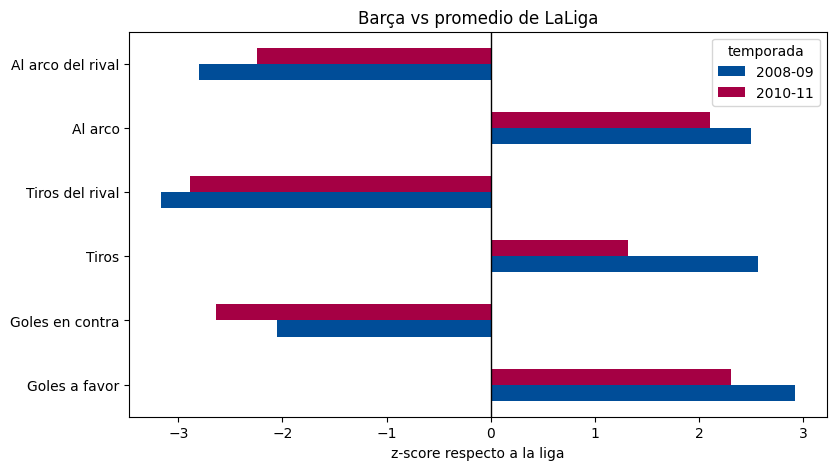

temporada,2008-09,2010-11
Goles a favor,2.92,2.30
Goles en contra,-2.06,-2.63
Tiros,2.57,1.32
Tiros del rival,-3.17,-2.89
Al arco,2.49,2.10
Al arco del rival,-2.80,-2.24


In [ ]:
por_equipo = eq.groupby(['temporada', 'equipo'])[['gf', 'gc', 'tiros', 'tiros_rival', 'al_arco', 'al_arco_rival']].mean()
z = por_equipo.groupby('temporada').transform(lambda x: (x - x.mean()) / x.std())
z_barca = z.xs('Barcelona', level='equipo').T
z_barca.index = ['Goles a favor', 'Goles en contra', 'Tiros', 'Tiros del rival', 'Al arco', 'Al arco del rival']

z_barca.plot.barh(color=[AZUL, GRANA], figsize=(9, 5))
plt.axvline(0, color='black', lw=1)
plt.xlabel('z-score respecto a la liga')
plt.title('Barça vs promedio de LaLiga')
plt.show()
z_barca.round(2)

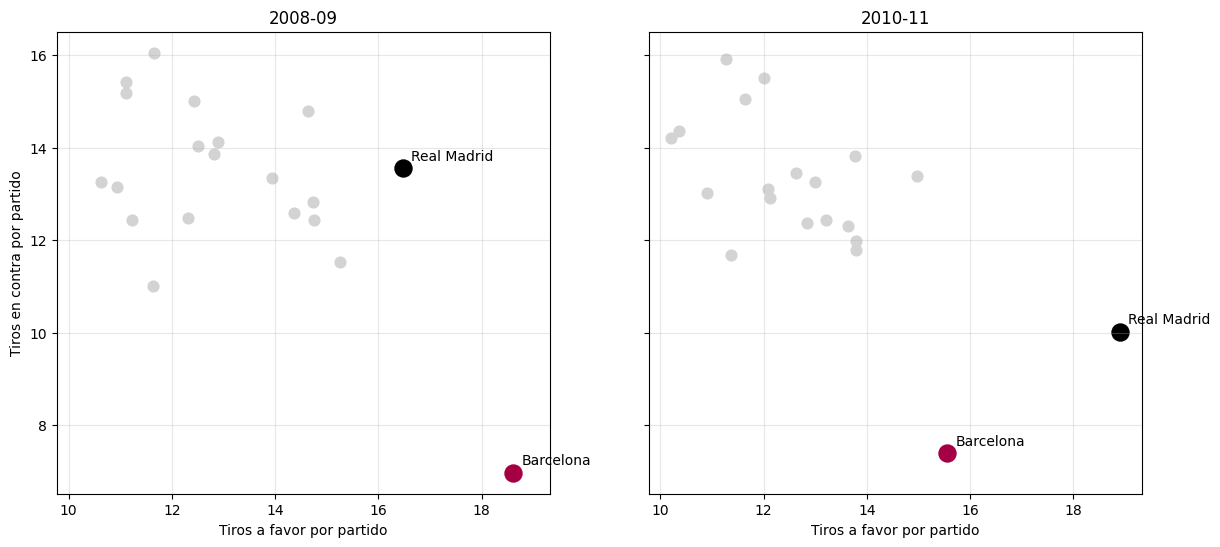

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
for ax, t in zip(axs, T):
    d = por_equipo.loc[t]
    ax.scatter(d.tiros, d.tiros_rival, color='lightgray', s=60)
    for equipo, color in [('Barcelona', GRANA), ('Real Madrid', 'black')]:
        ax.scatter(d.loc[equipo, 'tiros'], d.loc[equipo, 'tiros_rival'], color=color, s=150)
        ax.annotate(equipo, (d.loc[equipo, 'tiros'], d.loc[equipo, 'tiros_rival']), xytext=(6, 6), textcoords='offset points')
    ax.set_title(t)
    ax.set_xlabel('Tiros a favor por partido')
    ax.grid(alpha=.3)
axs[0].set_ylabel('Tiros en contra por partido')
plt.show()

Cada punto es un equipo. Abajo a la derecha significa que tira mucho y le tiran poco. El Barça está solo en esa esquina las dos temporadas. En 2010-11 se acerca más al resto en tiros a favor, y el Madrid aparece más cerca de él.

## Local vs visita y goles por tiempo

In [ ]:
lv = barca.groupby(['temporada', 'condicion']).agg(puntos_pp=('puntos', 'mean'), gf_pp=('gf', 'mean'), gc_pp=('gc', 'mean'))
lv.round(2)

puntos_pp  gf_pp  gc_pp
temporada condicion                         
2008-09   Local           2.37   3.21   0.74
          Visita          2.21   2.32   1.11
2010-11   Local           2.63   2.42   0.53
          Visita          2.42   2.58   0.58

In [ ]:
tiempos = g.agg(gf_1t=('gf_1t', 'sum'), gc_1t=('gc_1t', 'sum'), gf_total=('gf', 'sum'), gc_total=('gc', 'sum'))
tiempos['gf_2t'] = tiempos.gf_total - tiempos.gf_1t
tiempos['gc_2t'] = tiempos.gc_total - tiempos.gc_1t
tiempos[['gf_1t', 'gf_2t', 'gc_1t', 'gc_2t']]

,gf_1t,gf_2t,gc_1t,gc_2t
temporada,,,,
2008-09,52,53,15,20
2010-11,42,53,8,13


# Estilo de juego con StatsBomb

Desde aquí los datos son de eventos: 31 partidos de 2008-09 y 33 de 2010-11. Por eso todo va **por partido** y no en totales.

In [ ]:
eb = eventos[eventos.equipo == 'Barcelona']
er = eventos[eventos.equipo != 'Barcelona']
k = ['temporada', 'match_id']

estilo = pd.DataFrame({
    'pases': eb[eb.tipo == 'Pass'].groupby(k).size(),
    'pases_rival': er[er.tipo == 'Pass'].groupby(k).size(),
    'pases_completos': eb[(eb.tipo == 'Pass') & (eb.resultado == 'Completo')].groupby(k).size(),
    'tiros': eb[eb.tipo == 'Shot'].groupby(k).size(),
    'tiros_rival': er[er.tipo == 'Shot'].groupby(k).size(),
    'xg': eb[eb.tipo == 'Shot'].groupby(k).xg.sum(),
    'xg_rival': er[er.tipo == 'Shot'].groupby(k).xg.sum(),
    'presiones': eb[eb.tipo == 'Pressure'].groupby(k).size(),
    'recuperaciones': eb[eb.tipo.isin(['Ball Recovery', 'Interception'])].groupby(k).size(),
    'recup_campo_rival': eb[eb.tipo.isin(['Ball Recovery', 'Interception']) & (eb.x > 60)].groupby(k).size(),
}).fillna(0)
estilo['posesion_%'] = estilo.pases / (estilo.pases + estilo.pases_rival) * 100
estilo['acierto_pase_%'] = estilo.pases_completos / estilo.pases * 100
estilo['xg_por_tiro'] = estilo.xg / estilo.tiros
estilo['xg_rival_por_tiro'] = estilo.xg_rival / estilo.tiros_rival

estilo.groupby('temporada').mean().round(2).T

temporada,2008-09,2010-11
pases,611.23,789.85
pases_rival,334.71,323.45
pases_completos,507.97,696.70
tiros,18.58,15.18
tiros_rival,6.10,7.21
xg,2.34,1.86
xg_rival,0.62,0.70
presiones,121.42,119.18
recuperaciones,64.97,60.97
recup_campo_rival,28.81,25.79


La posesión está aproximada como la proporción de pases de cada equipo, que es la forma estándar cuando no hay datos de tiempo con balón.

Aquí está la identidad del equipo de 2010-11. Dio **790 pases por partido contra 611**, subió la posesión de 64.5% a 70.7% y el acierto de pase de 82.6% a 87.9%. A cambio tiró menos (de 18.6 a 15.2) y generó menos xG por partido (de 2.34 a 1.86). La calidad media de cada tiro fue casi la misma. Las presiones por partido se mantuvieron (121 contra 119), así que el equipo no presionó menos; con más posesión simplemente tuvo menos balones que recuperar (de 65 a 61 recuperaciones por partido).

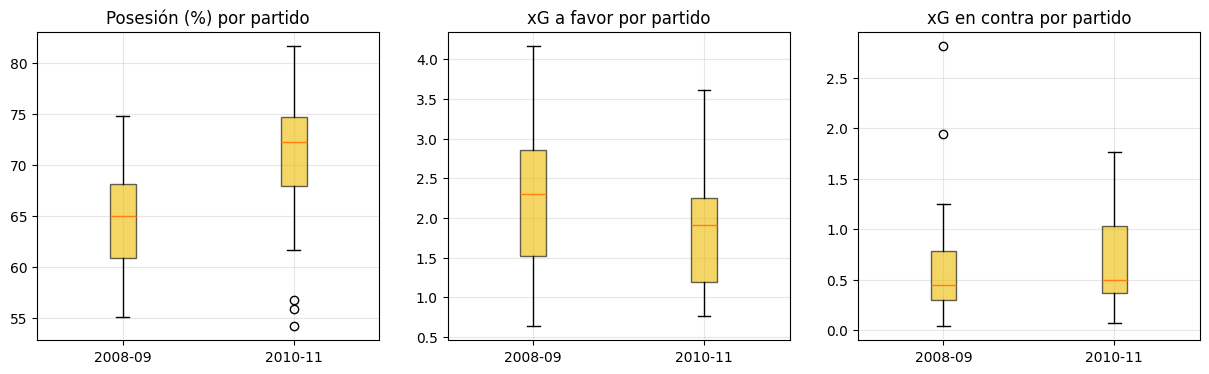

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, titulo in zip(axs, ['posesion_%', 'xg', 'xg_rival'], ['Posesión (%)', 'xG a favor', 'xG en contra']):
    datos = [estilo.loc[t, col] for t in T]
    ax.boxplot(datos, patch_artist=True, boxprops=dict(facecolor=ORO, alpha=.6))
    ax.set_xticks([1, 2], T)
    ax.set_title(titulo + ' por partido')
    ax.grid(alpha=.3)
plt.show()

## Mapa de calor del equipo

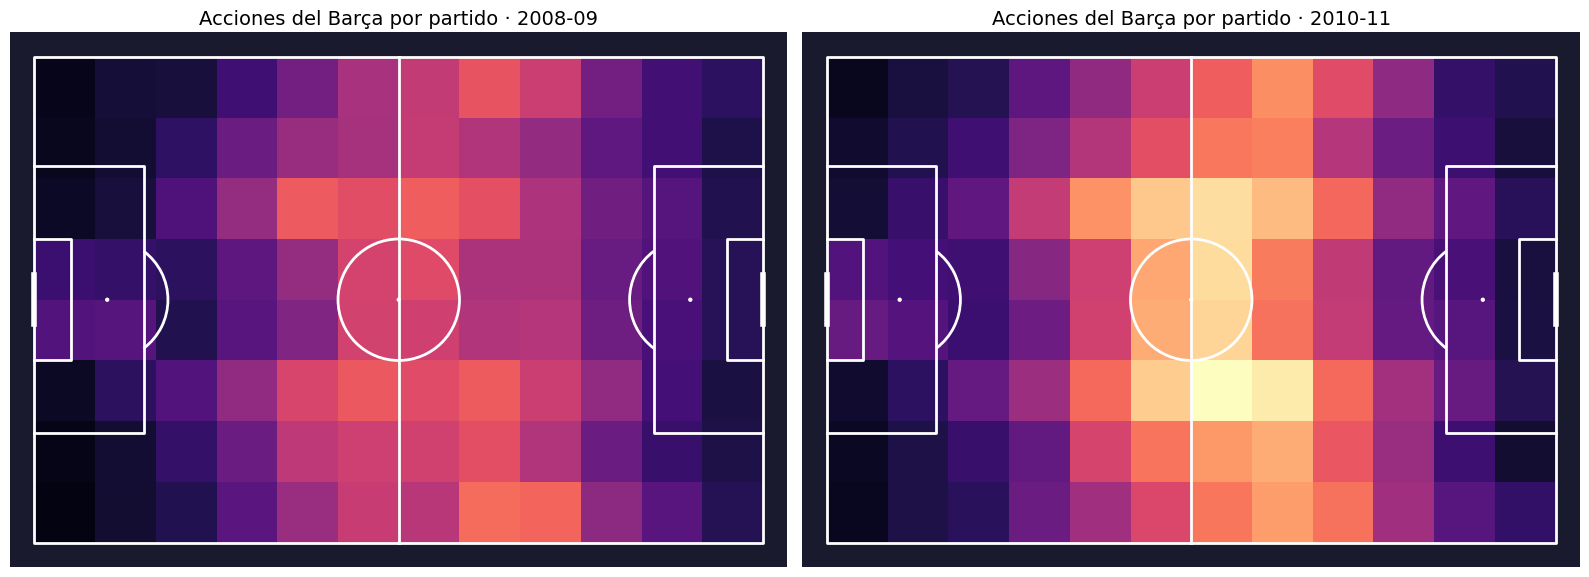

In [ ]:
pitch = Pitch(pitch_type='statsbomb', line_zorder=2, pitch_color='#1a1a2e', line_color='white')
n_partidos = partidos.groupby('temporada').size()

stats = {}
for t in T:
    d = eb[eb.temporada == t]
    s = pitch.bin_statistic(d.x, d.y, statistic='count', bins=(12, 8))
    s['statistic'] = s['statistic'] / n_partidos[t]
    stats[t] = s

vmax = max(s['statistic'].max() for s in stats.values())
fig, axs = pitch.draw(nrows=1, ncols=2, figsize=(16, 6))
for ax, t in zip(axs, T):
    pitch.heatmap(stats[t], ax=ax, cmap='magma', vmin=0, vmax=vmax)
    ax.set_title(f'Acciones del Barça por partido · {t}', fontsize=14)
plt.show()

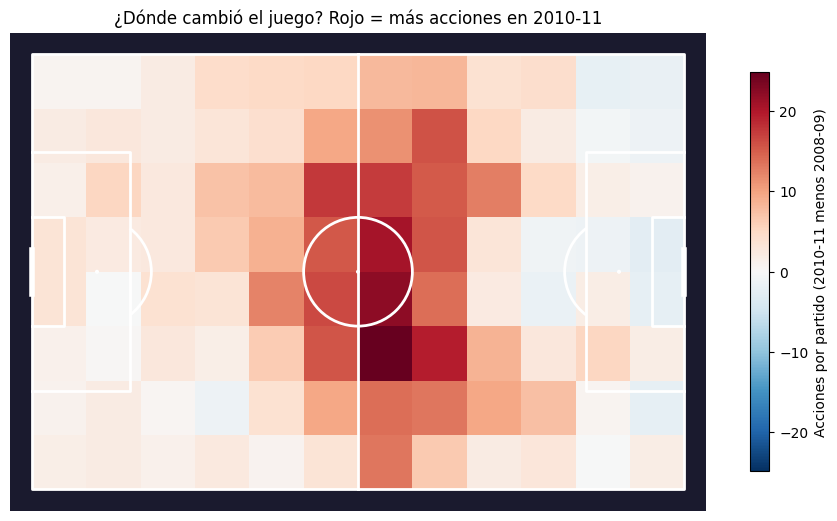

In [ ]:
dif = stats['2010-11'].copy()
dif['statistic'] = stats['2010-11']['statistic'] - stats['2008-09']['statistic']
lim = abs(dif['statistic']).max()

fig, ax = pitch.draw(figsize=(9, 6))
pc = pitch.heatmap(dif, ax=ax, cmap='RdBu_r', vmin=-lim, vmax=lim)
fig.colorbar(pc, ax=ax, shrink=.7, label='Acciones por partido (2010-11 menos 2008-09)')
ax.set_title('¿Dónde cambió el juego? Rojo = más acciones en 2010-11')
plt.show()

El mapa de diferencias es casi todo rojo porque en 2010-11 el equipo tocó más la pelota en general. El aumento se concentra en el **círculo central y la mitad de campo rival**, que es donde Xavi, Iniesta, Busquets y Messi (ya de falso 9) hacían circular el balón. En 2008-09 el juego se cargaba más hacia la banda derecha del último tercio (abajo a la derecha del mapa), la zona de Messi y Dani Alves.

## Dónde recupera el balón

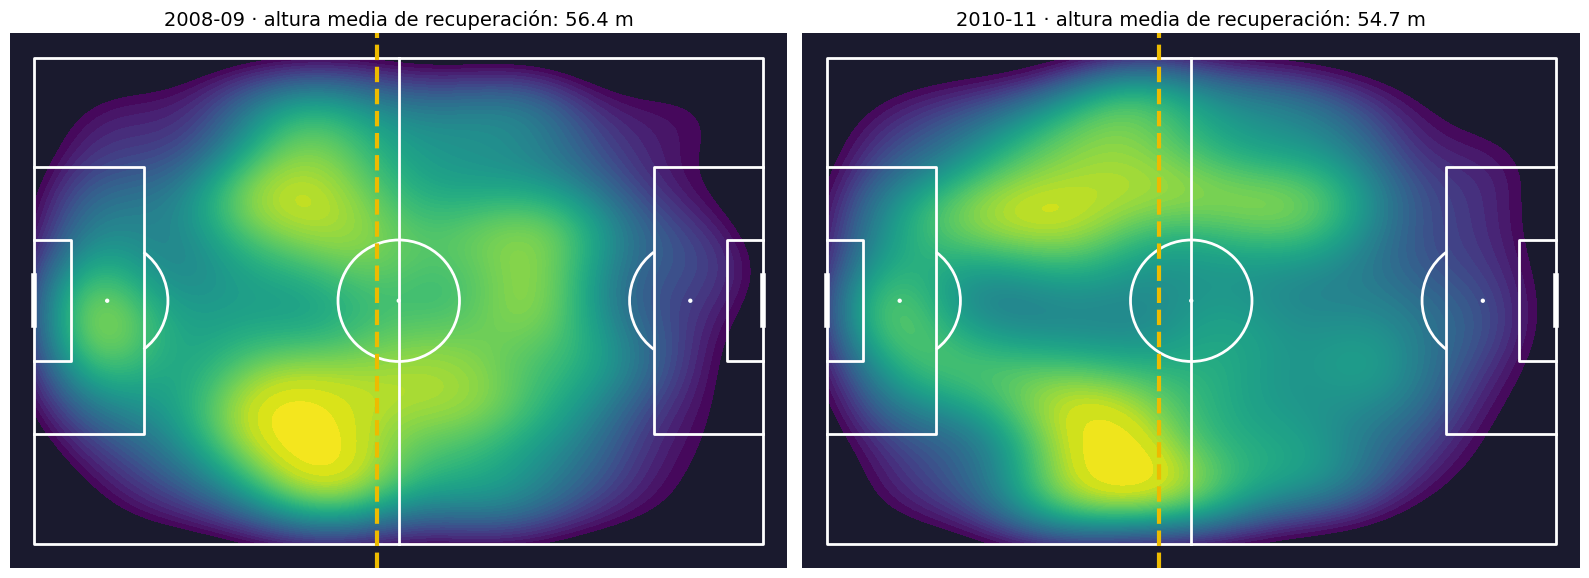

,count,mean,std,min,25%,50%,75%,max
temporada,,,,,,,,
2008-09,2014.0,56.4,29.8,1.2,33.9,55.3,79.8,119.8
2010-11,2012.0,54.7,30.0,0.2,31.7,53.2,78.1,118.9


In [ ]:
rec = eb[eb.tipo.isin(['Ball Recovery', 'Interception'])]
fig, axs = pitch.draw(nrows=1, ncols=2, figsize=(16, 6))
for ax, t in zip(axs, T):
    d = rec[rec.temporada == t]
    pitch.kdeplot(d.x, d.y, ax=ax, fill=True, levels=60, thresh=.05, cmap='viridis')
    ax.axvline(d.x.mean(), color=ORO, lw=3, ls='--')
    ax.set_title(f'{t} · altura media de recuperación: {d.x.mean():.1f} m', fontsize=14)
plt.show()

rec.groupby('temporada').x.describe().round(1)

las dos temporadas recuperaron el balón a una altura parecida (56.4 m y 54.7 m desde su propio arco). La presión alta ya existía en 2008-09. En ambas temporadas destaca la zona derecha del mediocampo, lo que tiene sentido porque Dani Alves era el jugador con más recuperaciones por 90 minutos.

## Mapas de tiros

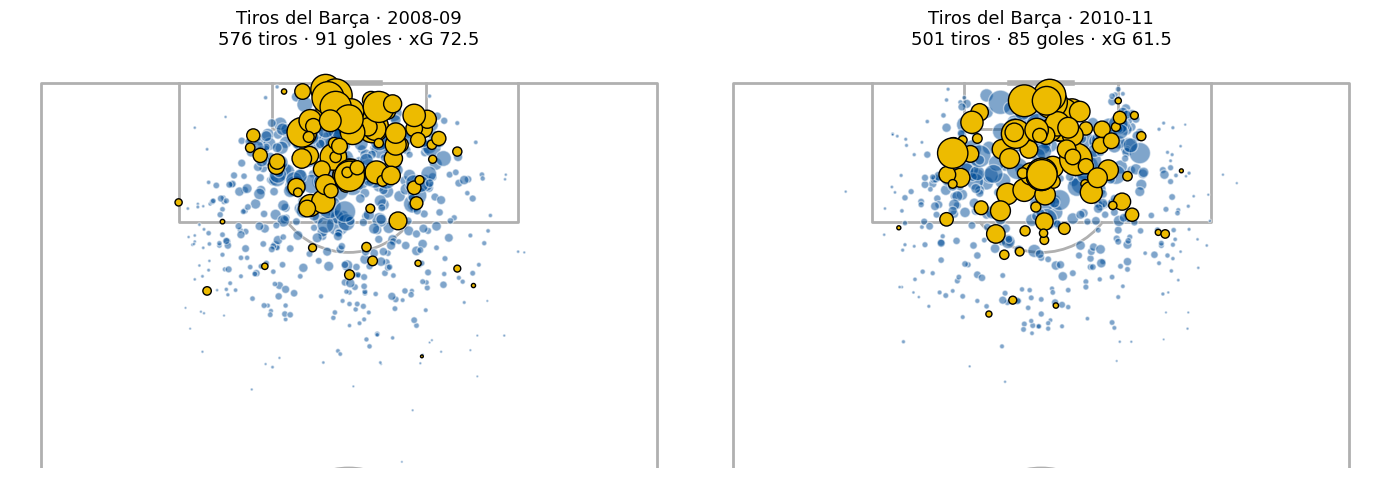

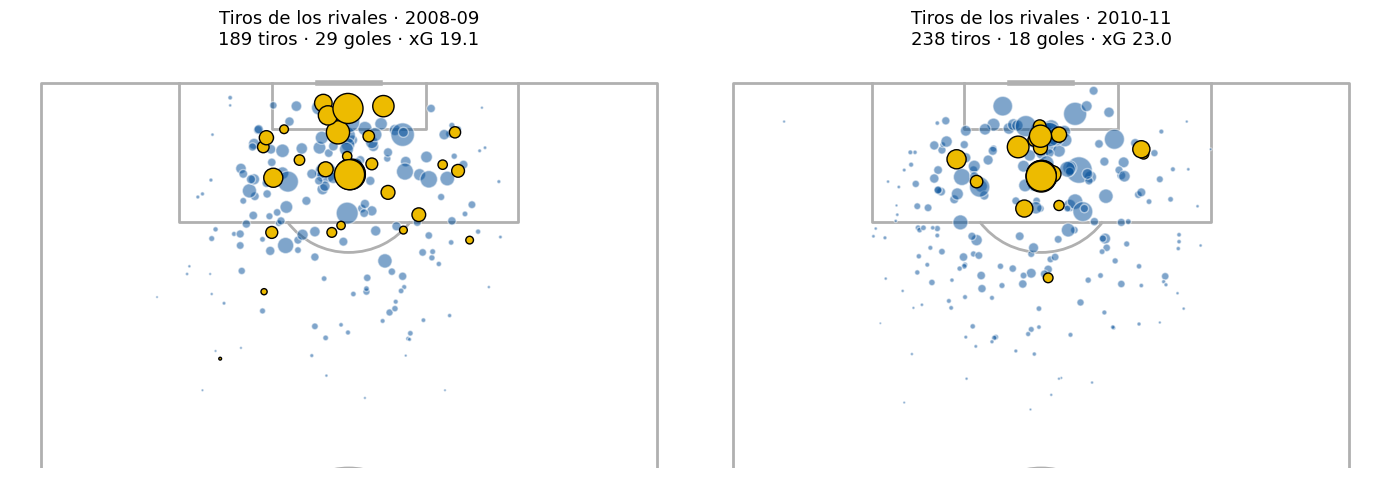

In [ ]:
tiros = eventos[eventos.tipo == 'Shot']
vpitch = VerticalPitch(pitch_type='statsbomb', half=True, pad_bottom=-10)

for equipo, titulo in [(True, 'Tiros del Barça'), (False, 'Tiros de los rivales')]:
    fig, axs = vpitch.draw(nrows=1, ncols=2, figsize=(14, 7))
    for ax, t in zip(axs, T):
        d = tiros[(tiros.temporada == t) & ((tiros.equipo == 'Barcelona') == equipo)]
        gol = d.resultado == 'Goal'
        vpitch.scatter(d[~gol].x, d[~gol].y, s=d[~gol].xg * 600, ax=ax, color=AZUL, alpha=.5, edgecolors='white')
        vpitch.scatter(d[gol].x, d[gol].y, s=d[gol].xg * 600, ax=ax, color=ORO, edgecolors='black')
        ax.set_title(f'{titulo} · {t}\n{len(d)} tiros · {gol.sum()} goles · xG {d.xg.sum():.1f}', fontsize=13)
    plt.show()

In [ ]:
tiros = tiros.assign(barca=tiros.equipo == 'Barcelona',
                     gol=tiros.resultado == 'Goal',
                     distancia=np.sqrt((120 - tiros.x) ** 2 + (40 - tiros.y) ** 2))
tabla_tiros = tiros.groupby(['temporada', 'barca']).agg(
    tiros=('gol', 'size'), goles=('gol', 'sum'), xg=('xg', 'sum'),
    xg_por_tiro=('xg', 'mean'), distancia_media=('distancia', 'mean'))
tabla_tiros['goles_menos_xg'] = tabla_tiros.goles - tabla_tiros.xg
tabla_tiros.round(2)

tiros  goles     xg  xg_por_tiro  distancia_media  \
temporada barca                                                      
2008-09   False    189     29  19.11         0.10            19.66   
          True     576     91  72.46         0.13            19.04   
2010-11   False    238     18  22.99         0.10            21.09   
          True     501     85  61.54         0.12            18.52   

                 goles_menos_xg  
temporada barca                  
2008-09   False            9.89  
          True            18.54  
2010-11   False           -4.99  
          True            23.46

Este es el hallazgo más importante del análisis. Los rivales no le generaron menos peligro en 2010-11 (en especial el Real Madrid :) ): tuvieron 23.0 de xG en 33 partidos contra 19.1 en 31 (0.70 contra 0.62 por partido). Lo que cambió es que en 2008-09 los rivales metieron **9.9 goles más** de lo esperado por la calidad de sus tiros, y en 2010-11 metieron **5.0 goles menos** de lo esperado. Esa diferencia de unos 15 goles se explica por la definición rival y por Valdés, no porque el equipo concediera menos ocasiones. En ataque el Barça superó a su xG las dos temporadas (+18.5 y +23.5), algo esperable con delanteros de ese nivel.

# Jugadores

Uso los minutos reales de cada jugador para calcular todo **por 90 minutos**, así no gana el que más jugó sino el que más produce. Filtro a los que jugaron al menos 900 minutos en los partidos de StatsBomb.

In [ ]:
mins = (minutos[minutos.equipo == 'Barcelona']
        .groupby(['temporada', 'jugador'])
        .agg(partidos=('match_id', 'nunique'), minutos=('minutos', 'sum')))

j = eb.assign(
    pase=eb.tipo == 'Pass',
    pase_ok=(eb.tipo == 'Pass') & (eb.resultado == 'Completo'),
    tiro=eb.tipo == 'Shot',
    gol=(eb.tipo == 'Shot') & (eb.resultado == 'Goal'),
    asistencia_gol=eb.asistencia == 'Gol',
    pase_clave=eb.asistencia.isin(['Gol', 'Tiro']),
    regate_ok=(eb.tipo == 'Dribble') & (eb.resultado == 'Complete'),
    recuperacion=eb.tipo.isin(['Ball Recovery', 'Interception']),
    presion=eb.tipo == 'Pressure')

cols = ['pase', 'pase_ok', 'tiro', 'gol', 'asistencia_gol', 'pase_clave', 'regate_ok', 'recuperacion', 'presion']
jug = j.groupby(['temporada', 'jugador'])[cols].sum()
jug['xg'] = j.groupby(['temporada', 'jugador']).xg.sum()
jug['acciones'] = j.groupby(['temporada', 'jugador']).size()
jug = mins.join(jug).fillna(0)
jug['acierto_pase_%'] = jug.pase_ok / jug.pase * 100

p90 = ['acciones', 'pase', 'gol', 'xg', 'asistencia_gol', 'pase_clave', 'regate_ok', 'recuperacion', 'presion']
for c in p90:
    jug[c + '_90'] = jug[c] / jug.minutos * 90

regulares = jug[jug.minutos >= 900]
regulares[['partidos', 'minutos', 'gol', 'xg', 'asistencia_gol', 'acierto_pase_%', 'pase_90', 'pase_clave_90', 'regate_ok_90', 'recuperacion_90']].round(2)

partidos  minutos  gol     xg  asistencia_gol  \
temporada jugador                                                            
2008-09   Andrés Iniesta           23     1779    2   3.18               5   
          Carles Puyol             25     2234    1   0.44               1   
          Dani Alves               29     2608    5   1.52               8   
          Gerard Piqué             21     1926    1   1.19               0   
          Lionel Messi             31     2593   23  16.93              11   
          Rafael Márquez           20     1819    1   0.97               0   
          Samuel Eto'o             29     2390   26  22.06               1   
          Sergio Busquets          23     1522    1   0.94               0   
          Seydou Kéita             24     1229    3   3.34               0   
          Thierry Henry            25     1868   17  11.97               7   
          Víctor Valdés            31     2875    0   0.00               0   
          Xavi                     31     2715    5   4.03              17   
          Yaya Touré               20     1496    1   0.26               1   
          Éric Abidal              20     1727    0   0.32               1   
2010-11   Andrés Iniesta           31     2581    8   3.14               3   
          Carles Puyol             15     1278    1   0.89               0   
          Dani Alves               30     2643    2   1.34              10   
          David Villa              31     2523   17  11.96               4   
          Gerard Piqué             29     2587    3   2.30               1   
          Javier Mascherano        23     1443    0   0.10               0   
          Lionel Messi             33     2944   31  24.17              18   
          Maxwell                  20     1527    0   0.14               0   
          Pedro                    29     1924   11   7.42               6   
          Sergio Busquets          25     2087    0   0.69               2   
          Seydou Kéita             31     1363    2   1.55               2   
          Víctor Valdés            28     2594    0   0.00               0   
          Xavi                     28     2238    2   1.90               7   
          Éric Abidal              23     1863    0   0.23               0   

                             acierto_pase_%  pase_90  pase_clave_90  \
temporada jugador                                                     
2008-09   Andrés Iniesta              85.74    62.43           2.07   
          Carles Puyol                84.21    51.04           0.24   
          Dani Alves                  79.26    72.71           1.79   
          Gerard Piqué                86.76    54.72           0.14   
          Lionel Messi                81.34    50.22           2.36   
          Rafael Márquez              85.90    61.40           0.25   
          Samuel Eto'o                76.23    29.94           0.90   
          Sergio Busquets             85.26    59.78           0.59   
          Seydou Kéita                83.38    52.87           0.88   
          Thierry Henry               72.29    33.73           1.35   
          Víctor Valdés               74.97    23.63           0.00   
          Xavi                        85.69    87.78           3.41   
          Yaya Touré                  90.32    60.88           0.66   
          Éric Abidal                 84.06    69.31           0.68   
2010-11   Andrés Iniesta              88.05    86.93           1.46   
          Carles Puyol                92.75    51.48           0.14   
          Dani Alves                  84.06    90.34           1.87   
          David Villa                 77.48    27.72           0.89   
          Gerard Piqué                89.22    67.42           0.28   
          Javier Mascherano           92.52    86.69           0.31   
          Lionel Messi                84.20    71.02           2.05   
          Maxwell                     85.88    74.32   

## Goles y asistencias

In [ ]:
top = jug[jug.gol + jug.asistencia_gol >= 6][['gol', 'xg', 'asistencia_gol']].sort_values('gol', ascending=False)
top.round(1)

gol    xg  asistencia_gol
temporada jugador                                  
2010-11   Lionel Messi     31  24.2              18
2008-09   Samuel Eto'o     26  22.1               1
          Lionel Messi     23  16.9              11
2010-11   David Villa      17  12.0               4
2008-09   Thierry Henry    17  12.0               7
2010-11   Pedro            11   7.4               6
          Andrés Iniesta    8   3.1               3
2008-09   Xavi              5   4.0              17
          Dani Alves        5   1.5               8
2010-11   Bojan             5   3.3               2
2008-09   Andrés Iniesta    2   3.2               5
2010-11   Dani Alves        2   1.3              10
          Xavi              2   1.9               7

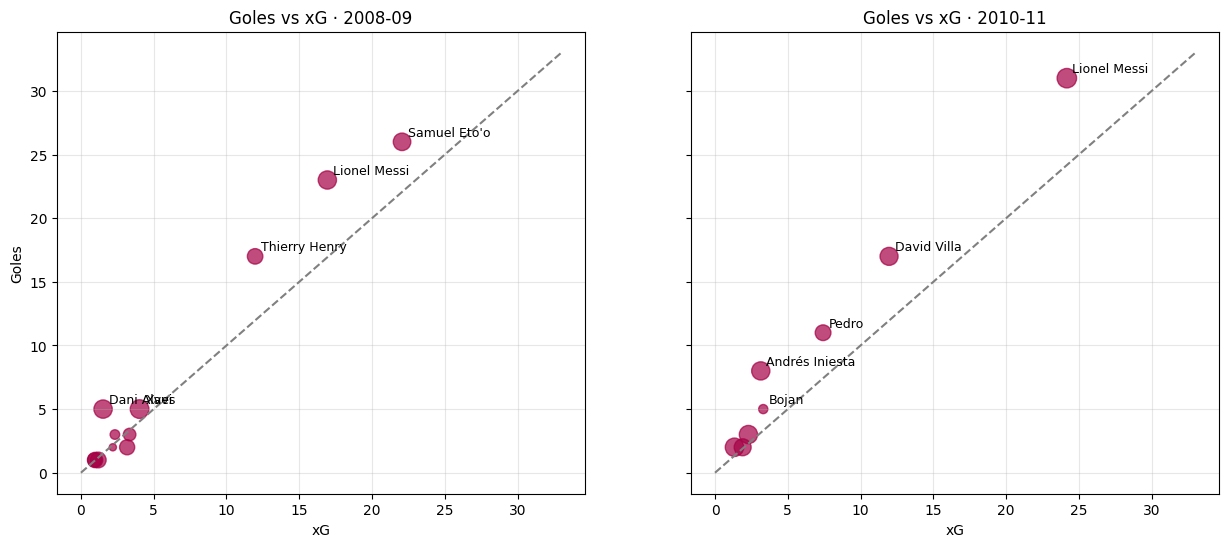

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)
for ax, t in zip(axs, T):
    d = jug.loc[t]
    d = d[d.tiro >= 10]
    ax.scatter(d.xg, d.gol, s=d.minutos / 15, color=GRANA, alpha=.7)
    for nombre, fila in d[d.gol >= 4].iterrows():
        ax.annotate(nombre, (fila.xg, fila.gol), xytext=(4, 4), textcoords='offset points', fontsize=9)
    m = max(jug.xg.max(), jug.gol.max()) + 2
    ax.plot([0, m], [0, m], ls='--', color='gray')
    ax.set_title(f'Goles vs xG · {t}')
    ax.set_xlabel('xG')
    ax.grid(alpha=.3)
axs[0].set_ylabel('Goles')
plt.show()

Encima de la línea gris = metió más goles de los que se esperaban por la calidad de sus tiros.

En 2008-09 el gol estaba repartido entre tres: Eto'o (26), Messi (23) y Henry (17). En 2010-11 Messi se volvió el centro de todo, con **31 goles y 18 asistencias** en los partidos de StatsBomb. Superó a su xG por unos 6-7 goles las dos temporadas, así que su definición está por encima de lo normal de forma sostenida. Xavi fue el gran asistente de 2008-09 (17), pero en 2010-11 bajó a 7.

## Los que estuvieron en las dos temporadas

In [ ]:
ambos = ['Lionel Messi', 'Xavi', 'Andrés Iniesta', 'Dani Alves', 'Sergio Busquets', 'Gerard Piqué']
comp = jug.loc[(slice(None), ambos), ['minutos', 'acciones_90', 'pase_90', 'acierto_pase_%', 'pase_clave_90', 'regate_ok_90', 'recuperacion_90', 'gol_90']]
comp.round(2).unstack(0).swaplevel(axis=1).sort_index(axis=1)

temporada           2008-09                                        \
                acciones_90 acierto_pase_% gol_90 minutos pase_90   
jugador                                                             
Lionel Messi         222.31          81.34   0.80    2593   50.22   
Xavi                 285.28          85.69   0.17    2715   87.78   
Andrés Iniesta       236.41          85.74   0.10    1779   62.43   
Dani Alves           237.04          79.26   0.17    2608   72.71   
Sergio Busquets      209.68          85.26   0.06    1522   59.78   
Gerard Piqué         166.54          86.76   0.05    1926   54.72   

temporada                                                      2010-11  \
                pase_clave_90 recuperacion_90 regate_ok_90 acciones_90   
jugador                                                                  
Lionel Messi             2.36            6.14         6.39      279.08   
Xavi                     3.41            5.93         1.82      383.16   
Andrés Iniesta           2.07            5.67         3.04      307.73   
Dani Alves               1.79            8.59         2.14      288.66   
Sergio Busquets          0.59            7.75         1.48      290.40   
Gerard Piqué             0.14            6.40         0.19      203.45   

temporada                                                            \
                acierto_pase_% gol_90 minutos pase_90 pase_clave_90   
jugador                                                               
Lionel Messi             84.20   0.95    2944   71.02          2.05   
Xavi                     91.82   0.08    2238  124.38          2.41   
Andrés Iniesta           88.05   0.28    2581   86.93          1.46   
Dani Alves               84.06   0.07    2643   90.34          1.87   
Sergio Busquets          91.78   0.00    2087   92.80          0.65   
Gerard Piqué             89.22   0.10    2587   67.42          0.28   

temporada                                     
                recuperacion_90 regate_ok_90  
jugador                                       
Lionel Messi               4.89         7.58  
Xavi                       5.35         1.77  
Andrés Iniesta             5.96         3.70  
Dani Alves                 7.29         2.18  
Sergio Busquets            5.82         1.51  
Gerard Piqué               5.18         0.31

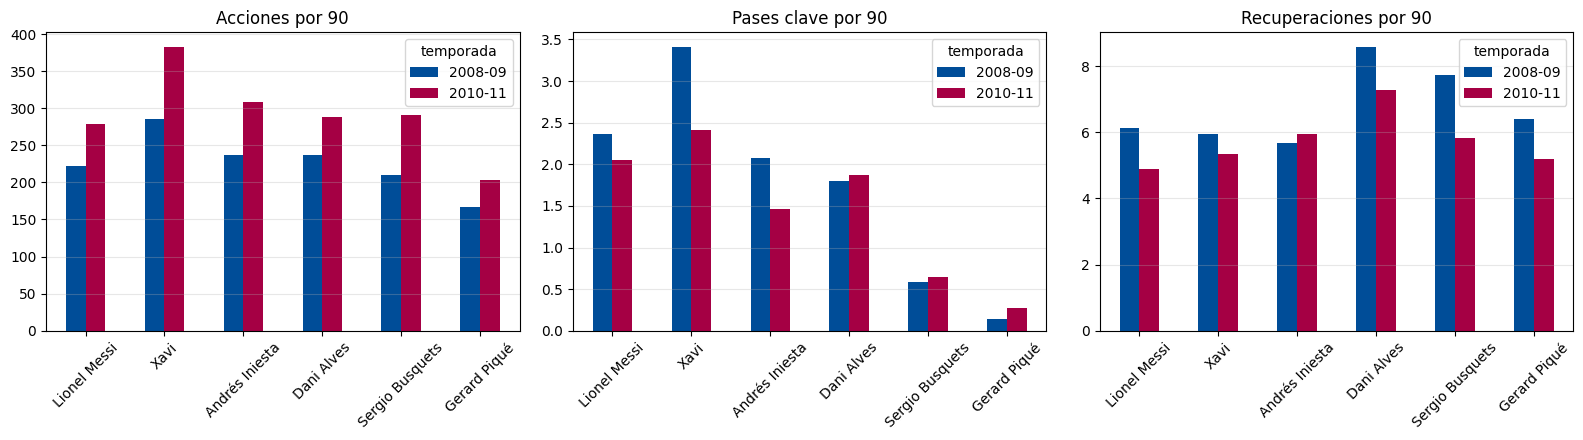

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, c, titulo in zip(axs, ['acciones_90', 'pase_clave_90', 'recuperacion_90'],
                         ['Acciones por 90', 'Pases clave por 90', 'Recuperaciones por 90']):
    comp[c].unstack(0).plot.bar(ax=ax, color=[AZUL, GRANA], rot=45)
    ax.set_title(titulo)
    ax.set_xlabel('')
    ax.grid(alpha=.3, axis='y')
plt.tight_layout()
plt.show()

**Lectura:** todos los que estuvieron en ambas temporadas participaron más en 2010-11. El caso más fuerte es Xavi: de 88 a **124 pases por 90 minutos** y de 85.7% a 91.8% de acierto. Busquets pasó de 60 a 93 pases con 91.8% de acierto, ya como titular fijo. Pero Xavi dio menos pases clave (de 3.4 a 2.4 por 90): pasó de dar el último pase a manejar la circulación, y el último pase quedó más en manos de Messi y Alves. Las recuperaciones por 90 bajaron en casi todos, lo que coincide con tener más la pelota.

## Mapas de calor por jugador

In [ ]:
def mapas(lista):
    fig, axs = pitch.draw(nrows=1, ncols=len(lista), figsize=(8 * len(lista), 6))
    for ax, (nombre, t) in zip(np.atleast_1d(axs), lista):
        d = eb[(eb.jugador == nombre) & (eb.temporada == t)]
        m = jug.loc[(t, nombre), 'minutos']
        pitch.kdeplot(d.x, d.y, ax=ax, fill=True, levels=80, thresh=.03, cmap='hot')
        ax.scatter(d.x.mean(), d.y.mean(), color='cyan', s=200, zorder=5, edgecolors='black')
        ax.set_title(f'{nombre} · {t}\n{int(m)} min · {len(d) / m * 90:.0f} acciones por 90', fontsize=14)
    plt.show()

def mapa_jugador(nombre):
    mapas([(nombre, t) for t in T])

El punto celeste es la posición media del jugador. Recuerda: el Barça ataca hacia la derecha y la banda derecha queda abajo.

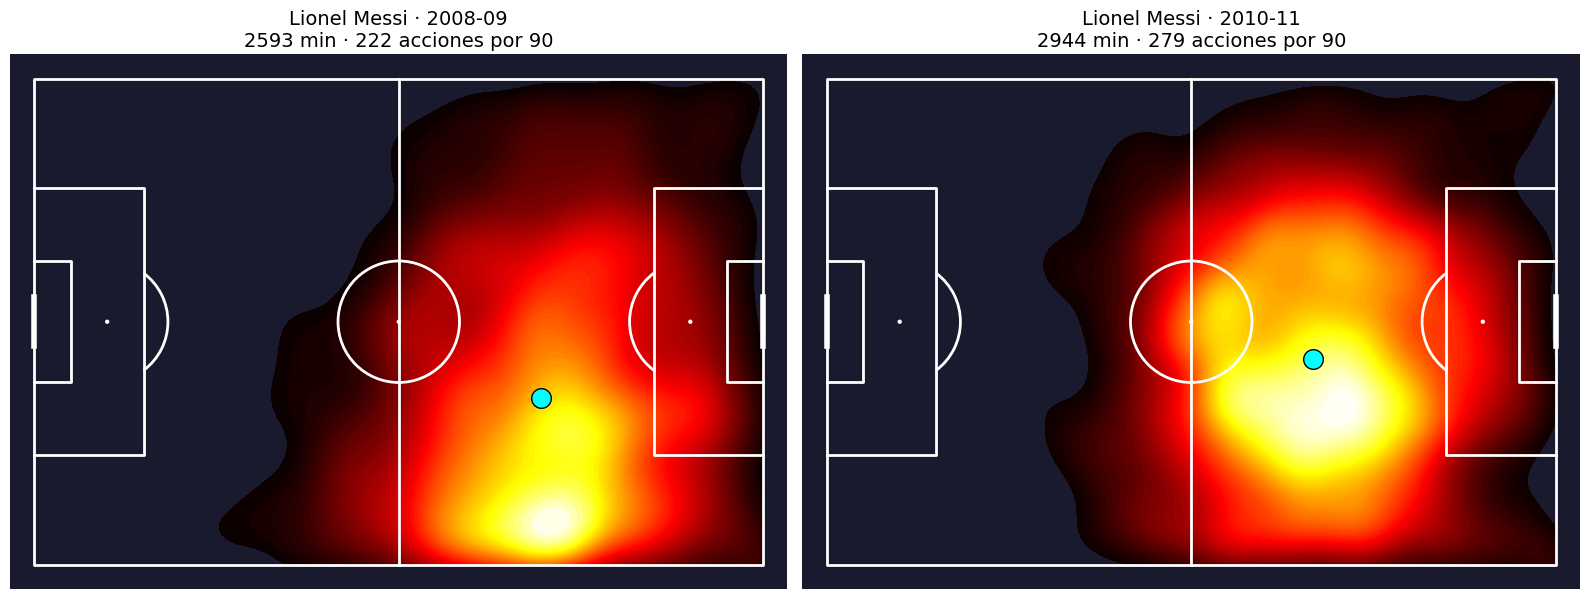

In [ ]:
mapa_jugador('Lionel Messi')

Es el cambio más claro de todo el análisis. En 2008-09 Messi jugaba pegado a la banda derecha. En 2010-11 su zona caliente pasa al centro, entre el mediocampo y el área: es el falso 9. También pasó de 222 a 279 acciones por 90 minutos.

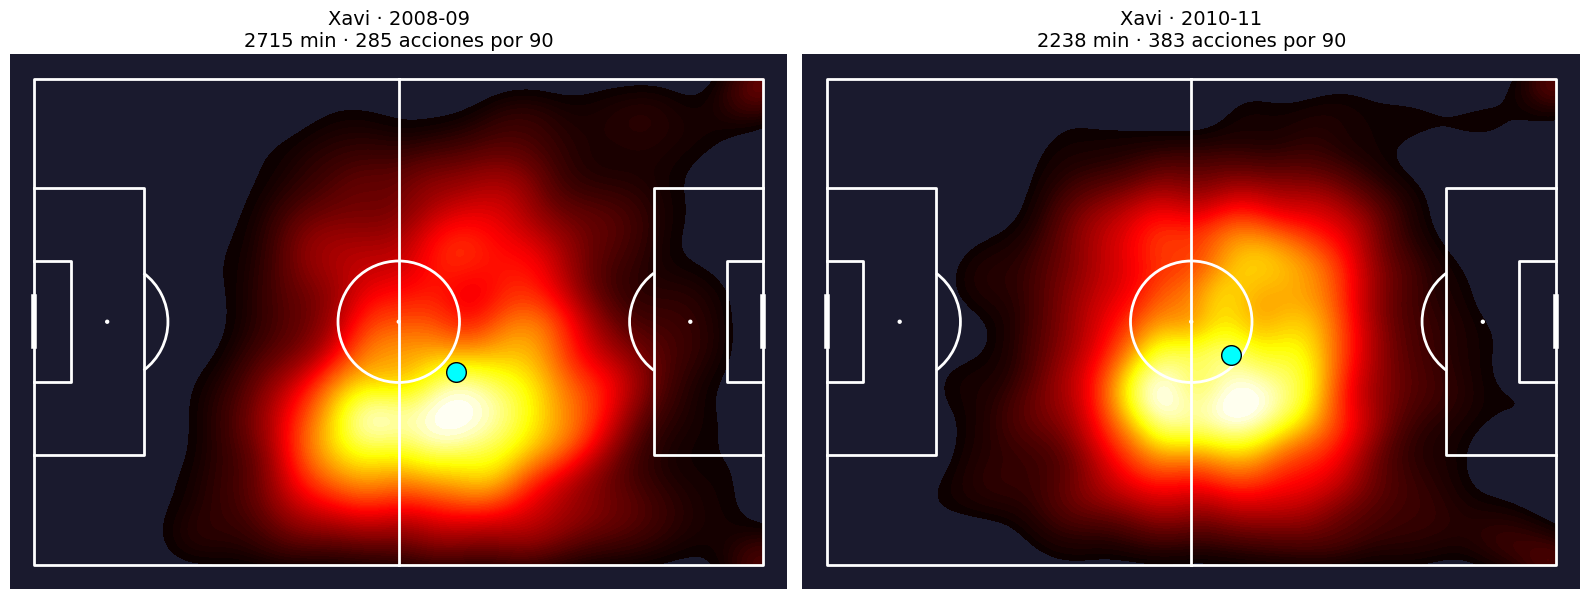

In [ ]:
mapa_jugador('Xavi')

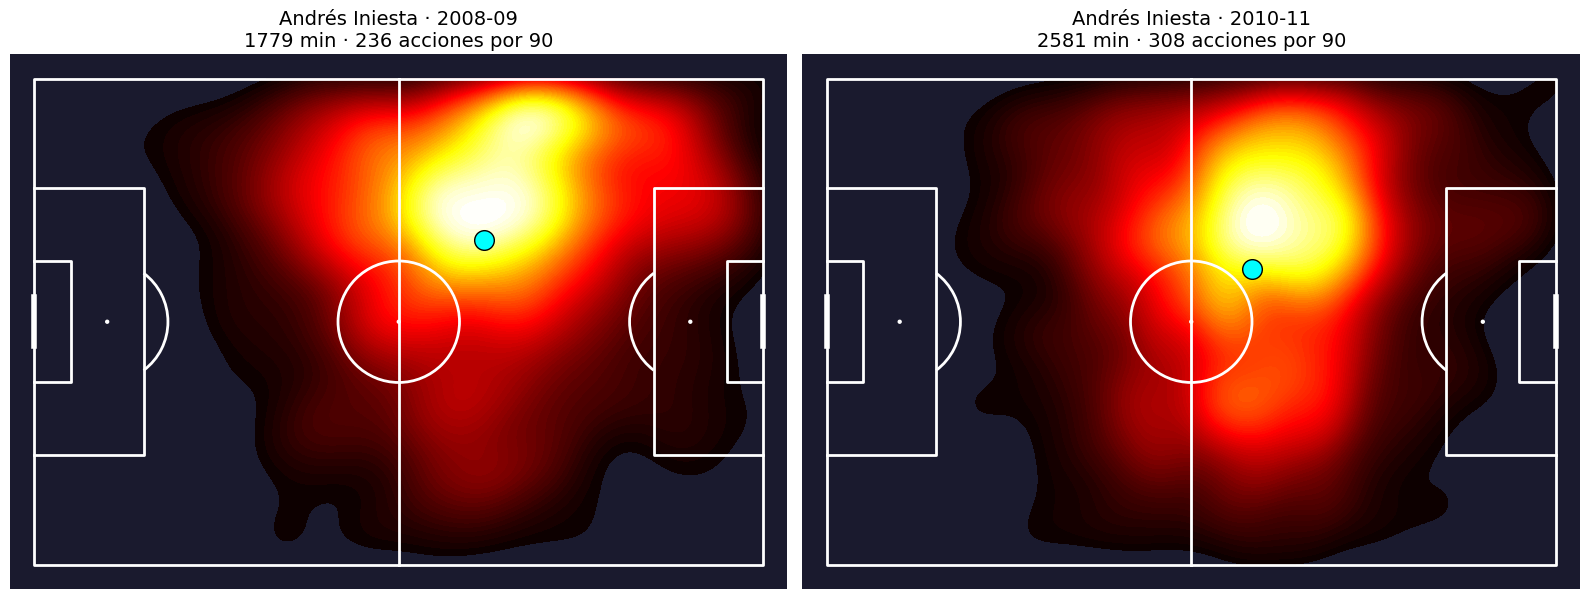

In [ ]:
mapa_jugador('Andrés Iniesta')

Xavi e Iniesta tocan más la pelota y se meten un poco más en campo rival en 2010-11. Las manchas son más intensas y están más cerca del círculo central, lo que coincide con el mapa de diferencias del equipo.

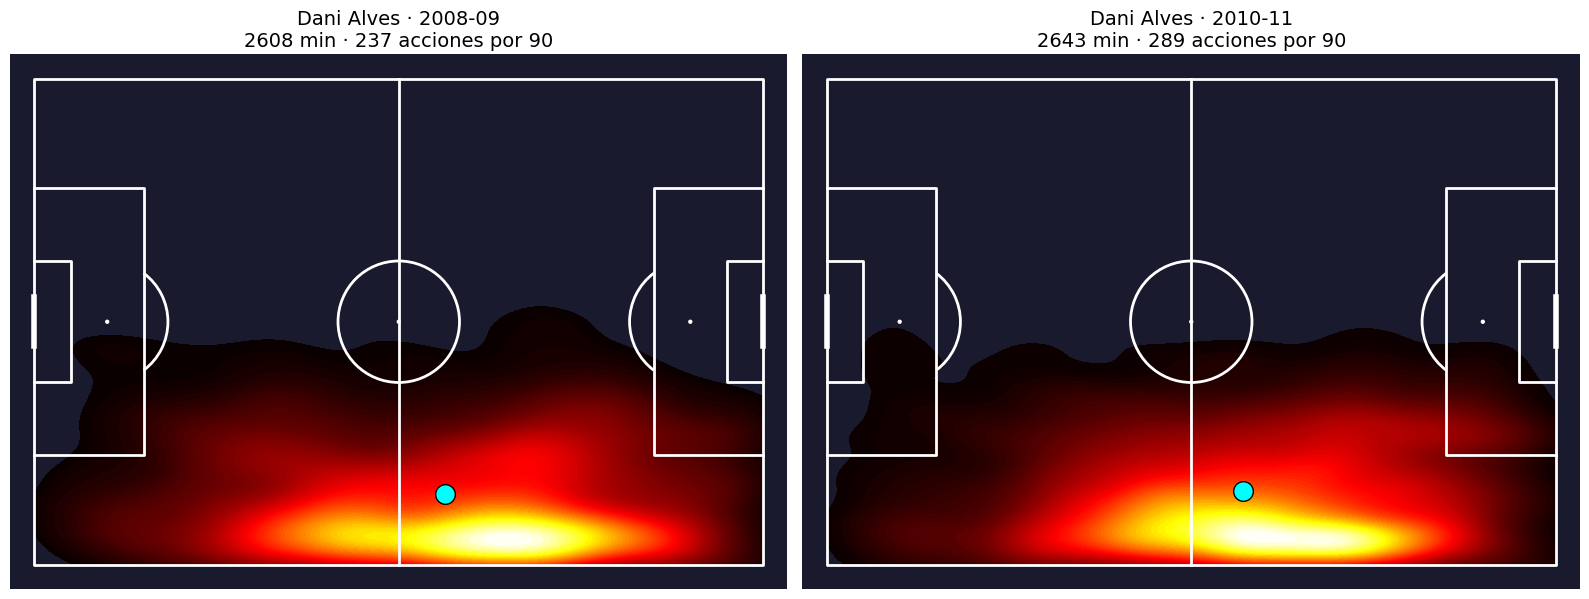

In [ ]:
mapa_jugador('Dani Alves')

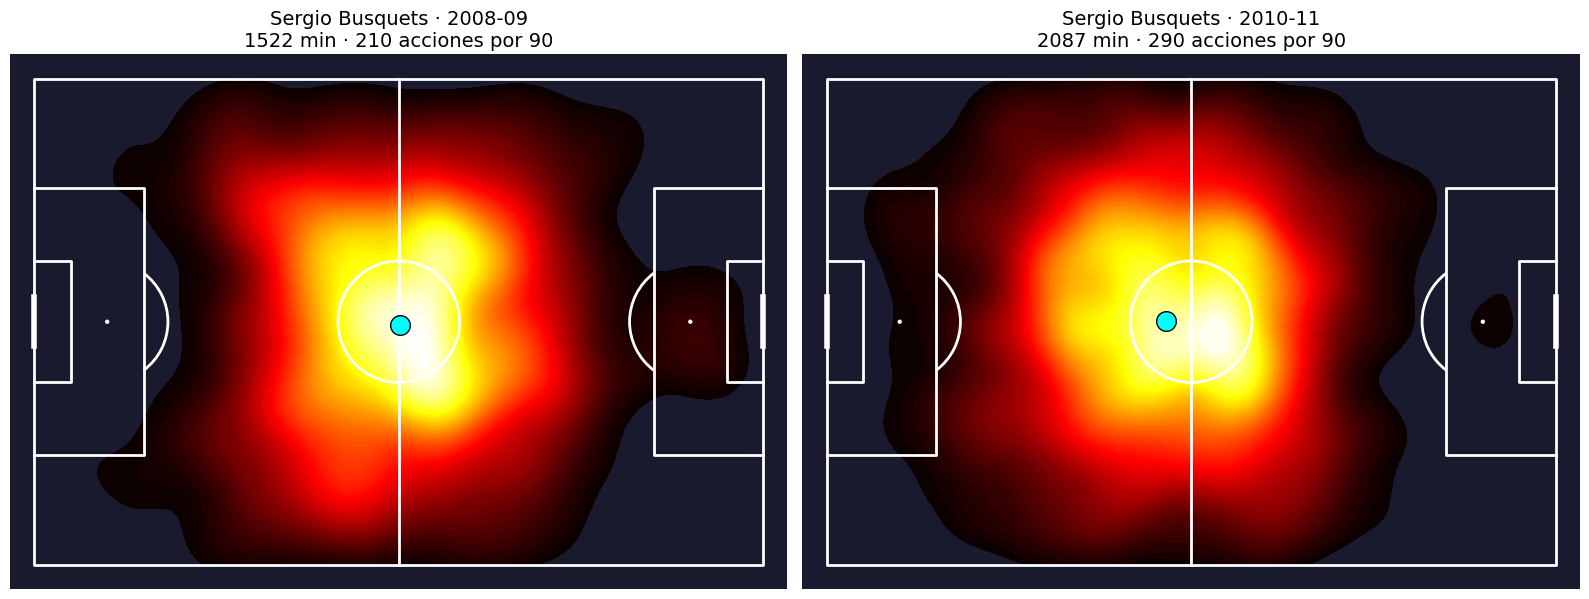

In [ ]:
mapa_jugador('Sergio Busquets')

Dani Alves ocupa toda la banda derecha las dos temporadas y llega muy arriba, como un extremo más. En 2010-11, con Messi por dentro, esa banda quedó prácticamente para él. Busquets en 2008-09 todavía alternaba con Yaya Touré; en 2010-11 ya es el pivote fijo delante de los centrales.

El 9 cambió de un año a otro, así que comparo a Eto'o (2008-09) con Villa (2010-11):

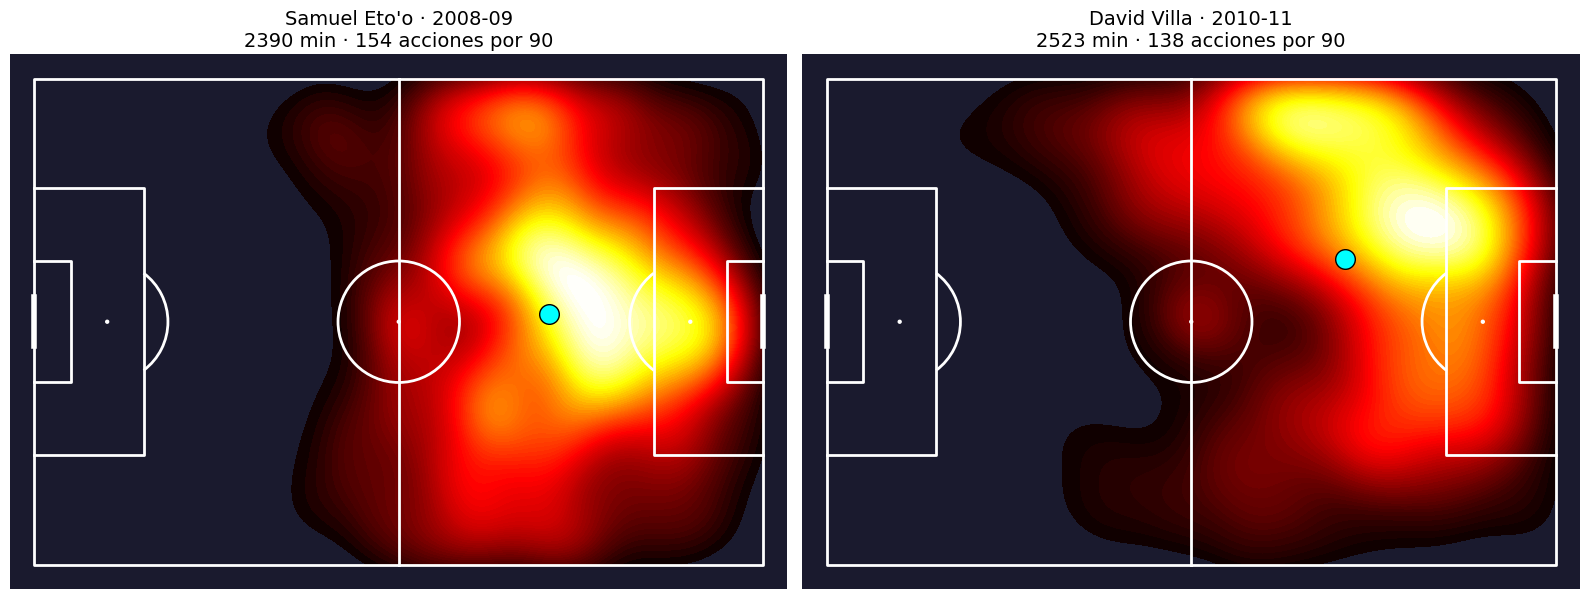

In [ ]:
mapas([("Samuel Eto'o", '2008-09'), ('David Villa', '2010-11')])

Eto'o era un 9 clásico, centrado y Villa, en cambio, partía desde la izquierda  para entrar en diagonal. Con Messi ocupando el centro, el delantero de 2010-11 tuvo que abrirse a la banda.

## C4. El cambio de Messi: de extremo a falso 9

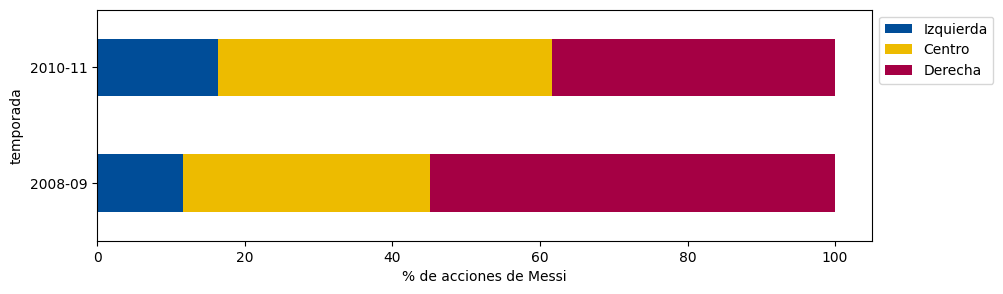

carril,Izquierda,Centro,Derecha
temporada,,,
2008-09,11.6,33.4,54.9
2010-11,16.4,45.3,38.3


In [ ]:
messi = eb[eb.jugador == 'Lionel Messi'].copy()
messi['carril'] = pd.cut(messi.y, [0, 26.67, 53.33, 80], labels=['Izquierda', 'Centro', 'Derecha'], include_lowest=True)
carriles = pd.crosstab(messi.temporada, messi.carril, normalize='index') * 100

carriles.plot.barh(stacked=True, color=[AZUL, ORO, GRANA], figsize=(10, 3))
plt.xlabel('% de acciones de Messi')
plt.legend(bbox_to_anchor=(1, 1))
plt.show()
carriles.round(1)

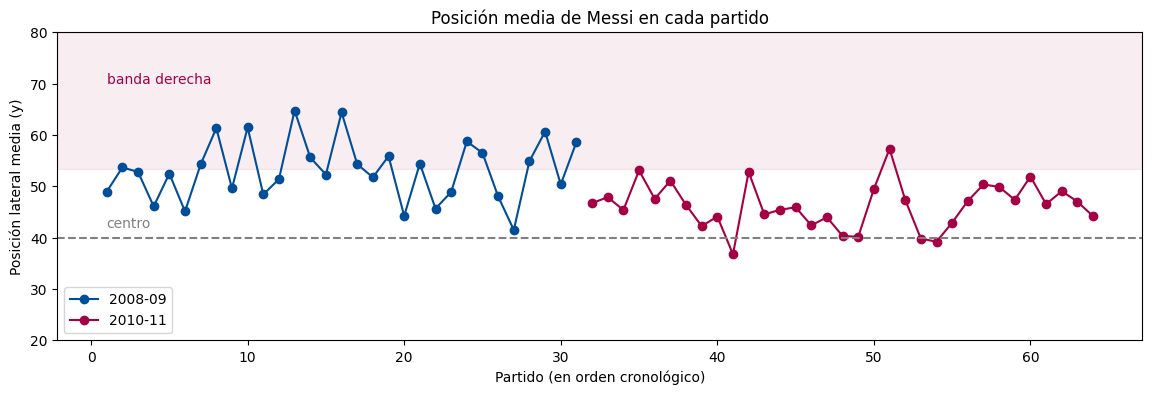

In [ ]:
pp = messi.groupby(['temporada', 'match_id']).agg(y_media=('y', 'mean'), x_media=('x', 'mean')).reset_index()
pp['partido'] = range(1, len(pp) + 1)

fig, ax = plt.subplots(figsize=(14, 4))
for t, color in zip(T, [AZUL, GRANA]):
    d = pp[pp.temporada == t]
    ax.plot(d.partido, d.y_media, 'o-', color=color, label=t)
ax.axhline(40, color='gray', ls='--')
ax.axhspan(53.33, 80, color=GRANA, alpha=.07)
ax.text(1, 70, 'banda derecha', color=GRANA)
ax.text(1, 42, 'centro', color='gray')
ax.set_ylim(20, 80)
ax.set_xlabel('Partido (en orden cronológico)')
ax.set_ylabel('Posición lateral media (y)')
ax.set_title('Posición media de Messi en cada partido')
ax.legend()
plt.show()

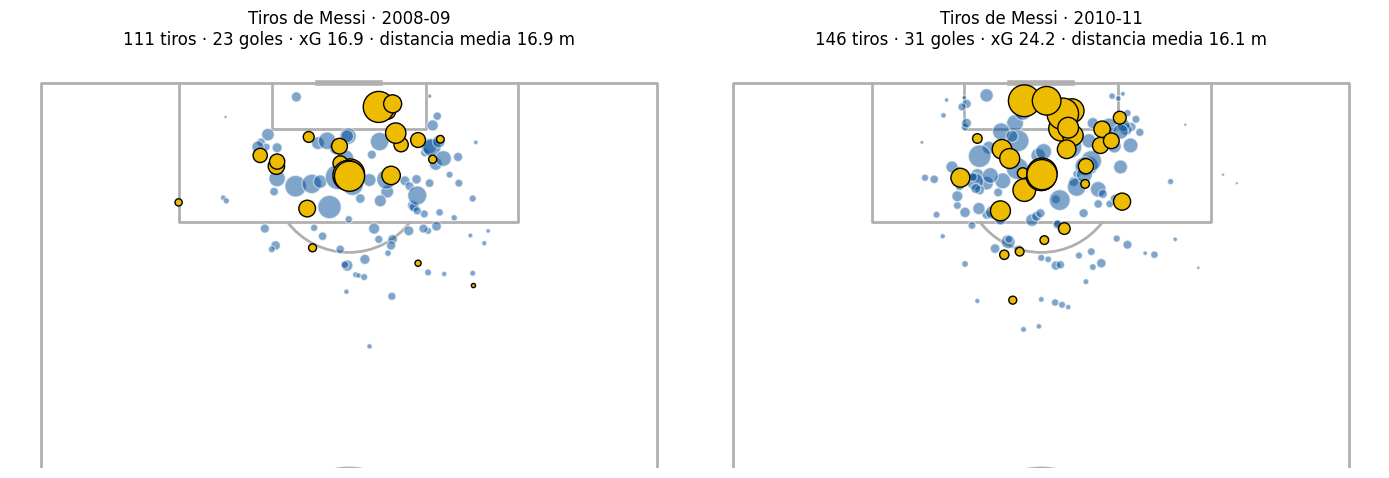

In [ ]:
fig, axs = vpitch.draw(nrows=1, ncols=2, figsize=(14, 7))
for ax, t in zip(axs, T):
    d = tiros[(tiros.jugador == 'Lionel Messi') & (tiros.temporada == t)]
    vpitch.scatter(d[~d.gol].x, d[~d.gol].y, s=d[~d.gol].xg * 600, ax=ax, color=AZUL, alpha=.5, edgecolors='white')
    vpitch.scatter(d[d.gol].x, d[d.gol].y, s=d[d.gol].xg * 600, ax=ax, color=ORO, edgecolors='black')
    ax.set_title(f'Tiros de Messi · {t}\n{len(d)} tiros · {d.gol.sum()} goles · xG {d.xg.sum():.1f} · distancia media {d.distancia.mean():.1f} m', fontsize=12)
plt.show()

## Red de pases

Uso a los 11 jugadores con más titularidades de cada temporada. Cada nodo está en la posición media desde donde pasa el jugador y su tamaño indica cuántos pases da. El grosor de la línea indica cuántos pases completos hubo entre esos dos jugadores por partido (solo se dibujan las conexiones con 3 o más por partido).

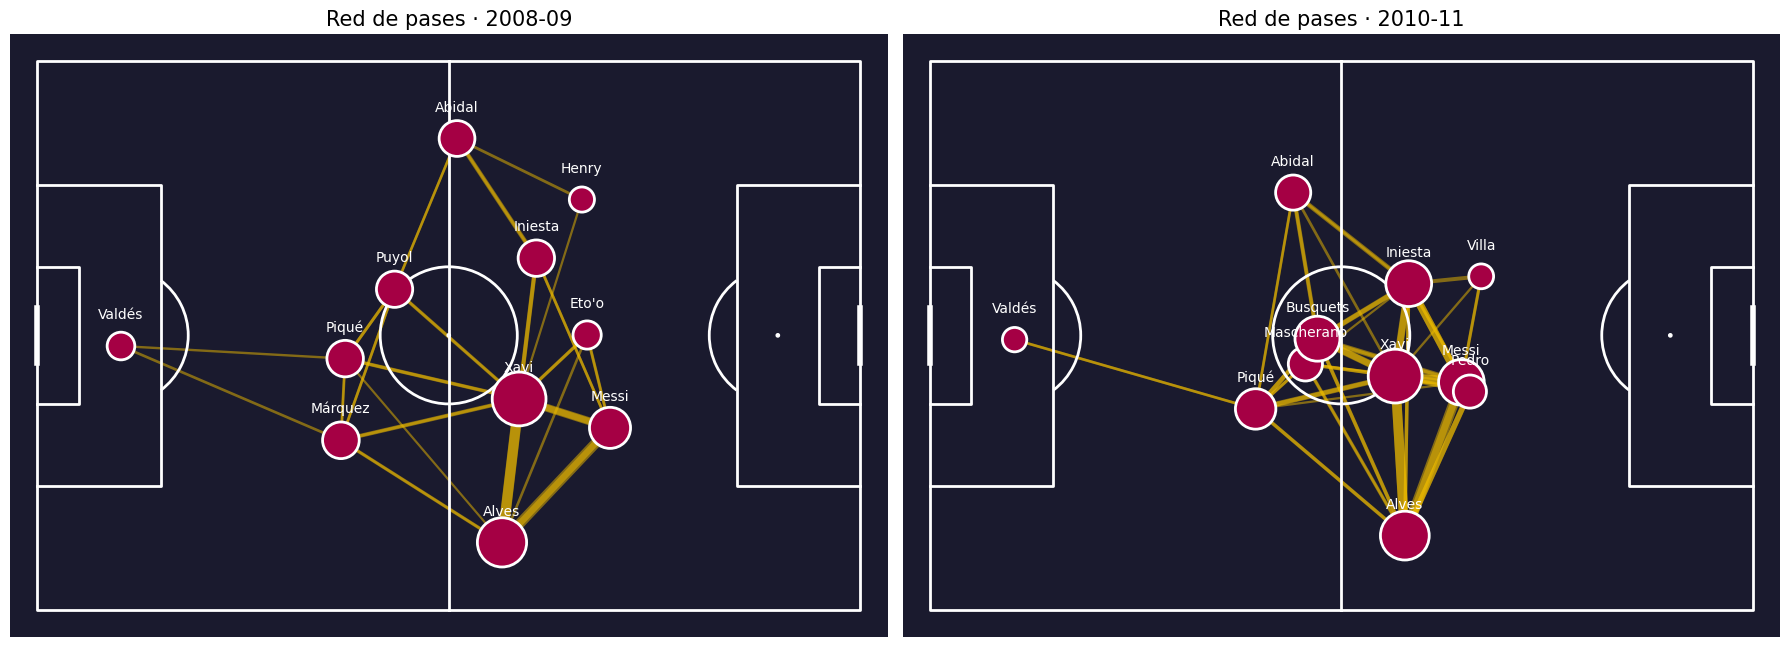

In [ ]:
titulares = minutos[minutos.equipo == 'Barcelona'].groupby(['temporada', 'jugador']).titular.sum()
pases_ok = eb[(eb.tipo == 'Pass') & (eb.resultado == 'Completo')]

fig, axs = pitch.draw(nrows=1, ncols=2, figsize=(18, 7))
for ax, t in zip(axs, T):
    once = titulares.loc[t].nlargest(11).index
    d = pases_ok[(pases_ok.temporada == t) & pases_ok.jugador.isin(once) & pases_ok.receptor.isin(once)]
    pos = d.groupby('jugador').agg(x=('x', 'mean'), y=('y', 'mean'), n=('x', 'size'))
    lazos = d.groupby(['jugador', 'receptor']).size().reset_index(name='n')
    lazos['n'] = lazos.n / n_partidos[t]
    lazos = lazos[lazos.n >= 3]
    for _, l in lazos.iterrows():
        a, b = pos.loc[l.jugador], pos.loc[l.receptor]
        pitch.lines(a.x, a.y, b.x, b.y, lw=l.n / 2, color=ORO, alpha=.5, ax=ax, zorder=1)
    pitch.scatter(pos.x, pos.y, s=pos.n / pos.n.max() * 1500, color=GRANA, edgecolors='white', lw=2, ax=ax, zorder=2)
    for nombre, p in pos.iterrows():
        pitch.annotate(nombre.split()[-1], (p.x, p.y - 4), ax=ax, color='white', ha='center', fontsize=10, zorder=3)
    ax.set_title(f'Red de pases · {t}', fontsize=15)
plt.show()

In [ ]:
for t in T:
    once = titulares.loc[t].nlargest(11).index
    d = pases_ok[(pases_ok.temporada == t) & pases_ok.jugador.isin(once) & pases_ok.receptor.isin(once)]
    top = d.groupby(['jugador', 'receptor']).size().div(n_partidos[t]).sort_values(ascending=False).head(5).round(1)
    print(t)
    print(top.to_string(), '\n')

2008-09
jugador       receptor    
Dani Alves    Xavi            15.1
              Lionel Messi    14.7
Xavi          Dani Alves      14.4
              Lionel Messi    11.4
Lionel Messi  Dani Alves       9.3 

2010-11
jugador       receptor    
Dani Alves    Lionel Messi    14.9
              Xavi            14.0
Xavi          Dani Alves      13.8
              Lionel Messi    13.3
Lionel Messi  Xavi            12.6 



# Conclusiones

1. **El Barça de 2010-11 sumó más puntos (96 contra 87) con menos goles (95 contra 105).** La mejora fue en goles recibidos (de 35 a 21).
2. **Esa mejora defensiva no vino de conceder menos ocasiones.** Los rivales tiraron al arco lo mismo (2.9 por partido) y tuvieron incluso un poco más de xG por partido (0.70 contra 0.62). Lo que cambió es que en 2008-09 los rivales definieron mucho mejor de lo esperado (+9.9 goles sobre su xG) y en 2010-11 peor (−5.0). Una parte importante de la diferencia es variabilidad en la definición rival y el rendimiento de Valdés.
3. **El estilo sí cambió de forma clara.** En 2010-11 el equipo dio casi 180 pases más por partido, tuvo 71% de posesión y 88% de acierto. Tiró menos pero mantuvo la calidad de tiro.
4. **El cambio táctico clave fue Messi.** Pasó de extremo derecho a falso 9: su presencia en la banda derecha bajó de 55% a 38% y la del centro subió de 33% a 45%. Con eso tuvo más tiros, más goles (31) y más asistencias (18).
5. **El mediocampo se volvió una máquina de circulación.** Xavi pasó a 124 pases por 90 con 92% de acierto y Busquets se consolidó como pivote. El último pase pasó de Xavi a Messi y Dani Alves.
6. **En 2008-09 el gol estaba más repartido** (Eto'o, Messi y Henry). En 2010-11 dependió mucho más de Messi, con Villa y Pedro abiertos para dejarle el centro.